This model script will analyze which ingredients Model 22 struggles with the most. Dishes below 5g of carbohydrates will once again be removed in order for them not to dominate the analysis, additionally will the values be normalized, so it wont get dominated by ingredients which shows up on a lot of dishes.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Imports and paths

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 100)

MODEL22_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator"
)

PRED_CSV = MODEL22_DIR / "model22_test_predictions_FIXED.csv"

METADATA_CSV = Path(
    "/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_ingredients_split_metadata.csv"
)

OUTPUT_DIR = MODEL22_DIR / "ingredient_percentage_error_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Prediction CSV:", PRED_CSV)
print("Metadata CSV:", METADATA_CSV)
print("Output directory:", OUTPUT_DIR)

print("\nFiles exist:")
print("Prediction CSV:", PRED_CSV.exists())
print("Metadata CSV:", METADATA_CSV.exists())

Prediction CSV: /content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/model22_test_predictions_FIXED.csv
Metadata CSV: /content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_ingredients_split_metadata.csv
Output directory: /content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/ingredient_percentage_error_analysis

Files exist:
Prediction CSV: True
Metadata CSV: True


Loading model 22 predictions

In [ ]:
pred_df = pd.read_csv(PRED_CSV)

print("Loaded Model 22 prediction CSV")
print("Shape:", pred_df.shape)

display(pred_df.head())
print(pred_df.columns.tolist())

Loaded Model 22 prediction CSV
Shape: (507, 215)


,dish_id,total_carb,split,source_cafe,rgb_carb_pred,pred_ingr_almonds,pred_ingr_apple,pred_ingr_artichokes,pred_ingr_arugula,pred_ingr_asparagus,pred_ingr_avocado,pred_ingr_baby_carrots,pred_ingr_bacon,pred_ingr_bagels,pred_ingr_banana_with_peel,pred_ingr_basil,pred_ingr_beef,pred_ingr_beets,pred_ingr_bell_peppers,pred_ingr_berries,pred_ingr_black_beans,pred_ingr_blackberries,pred_ingr_blue_cheese,pred_ingr_blueberries,pred_ingr_bok_choy,pred_ingr_bread,pred_ingr_broccoli,pred_ingr_brown_rice,pred_ingr_brown_sugar,pred_ingr_brownies,pred_ingr_brussels_sprouts,pred_ingr_bulgur,pred_ingr_butter,pred_ingr_buttermilk,pred_ingr_cabbage,pred_ingr_caesar_dressing,pred_ingr_caesar_salad,pred_ingr_cantaloupe,pred_ingr_carrot,pred_ingr_cauliflower,pred_ingr_celery,pred_ingr_celery_root,pred_ingr_cereal,pred_ingr_chard,pred_ingr_chayote_squash,pred_ingr_cheese,pred_ingr_cheese_pizza,pred_ingr_cherry_tomatoes,pred_ingr_chia_seeds,pred_ingr_chicken,pred_ingr_chicken_apple_sausage,pred_ingr_chicken_breast,pred_ingr_chicken_salad,pred_ingr_chicken_thighs,pred_ingr_chickpeas,pred_ingr_chilaquiles,pred_ingr_chili,pred_ingr_chive,pred_ingr_cilantro,pred_ingr_cod,pred_ingr_cookies,pred_ingr_corn,pred_ingr_corn_on_the_cob,pred_ingr_cottage_cheese,pred_ingr_country_rice,pred_ingr_couscous,pred_ingr_cranberries,pred_ingr_cream,pred_ingr_cream_cheese,pred_ingr_croutons,pred_ingr_cucumbers,pred_ingr_deprecated,pred_ingr_egg_whites,pred_ingr_eggplant,pred_ingr_eggs,pred_ingr_feta_cheese,pred_ingr_figs,pred_ingr_fish,pred_ingr_flour,pred_ingr_fried_rice,pred_ingr_frozen_yogurt,pred_ingr_fruit_salad,pred_ingr_garden_salad,pred_ingr_garlic,pred_ingr_ginger,pred_ingr_goat_cheese,pred_ingr_granola,pred_ingr_grapefruit_juice,pred_ingr_grapes,pred_ingr_greek_salad,pred_ingr_greek_yogurt,pred_ingr_green_beans,pred_ingr_green_onions,pred_ingr_grilled_chicken,pred_ingr_ground_turkey,pred_ingr_hash_browns,pred_ingr_hominy,pred_ingr_honeydew_melons,pred_ingr_ice_cream_cones,pred_ingr_jalapenos,pred_ingr_jicama,pred_ingr_kale,pred_ingr_ketchup,pred_ingr_kimchi,pred_ingr_lemon_juice,pred_ingr_lentils,pred_ingr_lettuce,pred_ingr_lime,pred_ingr_mandarin_oranges,pred_ingr_mangos,pred_ingr_mayonnaise,pred_ingr_milk,pred_ingr_millet,pred_ingr_mixed_greens,pred_ingr_mozzarella_cheese,pred_ingr_mushroom,pred_ingr_mustard,pred_ingr_mustard_greens,pred_ingr_nopales,pred_ingr_oatmeal,pred_ingr_olive_oil,pred_ingr_olives,pred_ingr_onions,pred_ingr_orange,pred_ingr_orange_juice,pred_ingr_orange_with_peel,pred_ingr_oregano,pred_ingr_parmesan_cheese,pred_ingr_parsley,pred_ingr_parsnips,pred_ingr_pasta,pred_ingr_pasta_salad,pred_ingr_pears,pred_ingr_pecans,pred_ingr_pepper,pred_ingr_pepperoni,pred_ingr_pepperoni_pizza,pred_ingr_pesto,pred_ingr_pickles,pred_ingr_pilaf,pred_ingr_pineapple,pred_ingr_pizza,pred_ingr_plate_only,pred_ingr_pork,pred_ingr_potatoes,pred_ingr_pumpkin_seeds,pred_ingr_quinoa,pred_ingr_radishes,pred_ingr_raisins,pred_ingr_raspberries,pred_ingr_rice_noodles,pred_ingr_roasted_potatoes,pred_ingr_rosemary,pred_ingr_salmon,pred_ingr_salsa,pred_ingr_salt,pred_ingr_sandwiches,pred_ingr_sausage,pred_ingr_scrambled_eggs,pred_ingr_shallots,pred_ingr_snow_peas,pred_ingr_sour_cream,pred_ingr_soy_sauce,pred_ingr_spinach_cooked,pred_ingr_spinach_raw,pred_ingr_squash,pred_ingr_steak,pred_ingr_strawberries,pred_ingr_succotash,pred_ingr_sugar,pred_ingr_sun_dried_tomatoes,pred_ingr_sunflower_seeds,pred_ingr_sweet_potato,pred_ingr_syrup,pred_ingr_tatsoi,pred_ingr_tempeh,pred_ingr_thyme,pred_ingr_toast,pred_ingr_tofu,pred_ingr_tomatillo,pred_ingr_tomatoes,pred_ingr_tortilla,pred_ingr_tortilla_chips,pred_ingr_tuna,pred_ingr_tuna_salad,pred_ingr_turkey_bacon,pred_ingr_turnips,pred_ingr_vegetable_oil,pred_ingr_vinaigrette,pred_ingr_vinegar,pred_ingr_waffles,pred_ingr_walnuts,pred_ingr_watermelon,pred_ingr_wheat_berry,pred_ingr_wheat_bread,pred_ingr_white_beans,pred_ingr_white_rice,pred_ingr_white_wine,pred_ingr_wild_rice,pred_ingr_wine,pred_ingr_yam,pred_ingr_yogurt,pred_ingr_zucch

['dish_id', 'total_carb', 'split', 'source_cafe', 'rgb_carb_pred', 'pred_ingr_almonds', 'pred_ingr_apple', 'pred_ingr_artichokes', 'pred_ingr_arugula', 'pred_ingr_asparagus', 'pred_ingr_avocado', 'pred_ingr_baby_carrots', 'pred_ingr_bacon', 'pred_ingr_bagels', 'pred_ingr_banana_with_peel', 'pred_ingr_basil', 'pred_ingr_beef', 'pred_ingr_beets', 'pred_ingr_bell_peppers', 'pred_ingr_berries', 'pred_ingr_black_beans', 'pred_ingr_blackberries', 'pred_ingr_blue_cheese', 'pred_ingr_blueberries', 'pred_ingr_bok_choy', 'pred_ingr_bread', 'pred_ingr_broccoli', 'pred_ingr_brown_rice', 'pred_ingr_brown_sugar', 'pred_ingr_brownies', 'pred_ingr_brussels_sprouts', 'pred_ingr_bulgur', 'pred_ingr_butter', 'pred_ingr_buttermilk', 'pred_ingr_cabbage', 'pred_ingr_caesar_dressing', 'pred_ingr_caesar_salad', 'pred_ingr_cantaloupe', 'pred_ingr_carrot', 'pred_ingr_cauliflower', 'pred_ingr_celery', 'pred_ingr_celery_root', 'pred_ingr_cereal', 'pred_ingr_chard', 'pred_ingr_chayote_squash', 'pred_ingr_cheese', 

Computing absolute error and percentage error

In [ ]:
target_col = "total_carb"
model22_col = "model22_pred"

required_cols = ["dish_id", target_col, model22_col]
missing_cols = [col for col in required_cols if col not in pred_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in prediction CSV: {missing_cols}")

pred_df["model22_abs_error"] = (
    pred_df[model22_col] - pred_df[target_col]
).abs()

pred_df["model22_percentage_error"] = np.where(
    pred_df[target_col] > 0,
    (pred_df["model22_abs_error"] / pred_df[target_col]) * 100,
    np.nan
)

display(
    pred_df[
        [
            "dish_id",
            target_col,
            model22_col,
            "model22_abs_error",
            "model22_percentage_error",
        ]
    ].head()
)

,dish_id,total_carb,model22_pred,model22_abs_error,model22_percentage_error
0,dish_1556575327,10.618,12.617384,1.999384,18.830138
1,dish_1557861216,0.000,2.983665,2.983665,NaN
2,dish_1557862345,0.000,2.987030,2.987030,NaN
3,dish_1557862696,3.850,3.917544,0.067544,1.754400
4,dish_1557862738,0.000,4.341109,4.341109,NaN


Removing dishes below 5g carbohydrates

In [ ]:
MIN_CARB_THRESHOLD = 5.0

analysis_df = pred_df[
    (pred_df[target_col] >= MIN_CARB_THRESHOLD) &
    (pred_df["model22_percentage_error"].notna())
].copy()

total_dishes_before_filter = len(pred_df)
num_kept = len(analysis_df)
num_removed = total_dishes_before_filter - num_kept

percentage_removed = (num_removed / total_dishes_before_filter) * 100
percentage_kept = (num_kept / total_dishes_before_filter) * 100

print("=" * 80)
print("5g carbohydrate filtering summary")
print("=" * 80)
print(f"Total dishes before filtering: {total_dishes_before_filter}")
print(f"Dishes removed below {MIN_CARB_THRESHOLD}g carbohydrates: {num_removed}")
print(f"Dishes kept after filtering: {num_kept}")
print(f"Percentage removed: {percentage_removed:.2f}%")
print(f"Percentage kept: {percentage_kept:.2f}%")

display(
    analysis_df[
        [
            "dish_id",
            target_col,
            model22_col,
            "model22_abs_error",
            "model22_percentage_error",
        ]
    ].head()
)

5g carbohydrate filtering summary
Total dishes before filtering: 507
Dishes removed below 5.0g carbohydrates: 127
Dishes kept after filtering: 380
Percentage removed: 25.05%
Percentage kept: 74.95%


,dish_id,total_carb,model22_pred,model22_abs_error,model22_percentage_error
0,dish_1556575327,10.618000,12.617384,1.999384,18.830138
9,dish_1557937037,5.880000,8.251269,2.371269,40.327704
11,dish_1557937157,14.700001,18.639410,3.939409,26.798699
12,dish_1557937335,11.172000,5.847211,5.324789,47.661914
17,dish_1557937758,18.932001,21.462584,2.530583,13.366696


Loading ingredient metadata

In [ ]:
metadata_df = pd.read_csv(METADATA_CSV)

print("Loaded prepared ingredient metadata")
print("Shape:", metadata_df.shape)
print("\nColumns:")
print(metadata_df.columns.tolist())

display(metadata_df.head())

Loaded prepared ingredient metadata
Shape: (3262, 205)

Columns:
['dish_id', 'total_mass', 'total_carb', 'split', 'source_cafe', 'num_ingredients', 'ingredient_list_str', 'ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy', 'ingr_bread', 'ingr_broccoli', 'ingr_brown_rice', 'ingr_brown_sugar', 'ingr_brownies', 'ingr_brussels_sprouts', 'ingr_bulgur', 'ingr_butter', 'ingr_buttermilk', 'ingr_cabbage', 'ingr_caesar_dressing', 'ingr_caesar_salad', 'ingr_cantaloupe', 'ingr_carrot', 'ingr_cauliflower', 'ingr_celery', 'ingr_celery_root', 'ingr_cereal', 'ingr_chard', 'ingr_chayote_squash', 'ingr_cheese', 'ingr_cheese_pizza', 'ingr_cherry_tomatoes', 'ingr_chia_seeds', 'ingr_chicken', 'ingr_chicken_apple_s

,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,ingr_arugula,ingr_asparagus,ingr_avocado,ingr_baby_carrots,ingr_bacon,ingr_bagels,ingr_banana_with_peel,ingr_basil,ingr_beef,ingr_beets,ingr_bell_peppers,ingr_berries,ingr_black_beans,ingr_blackberries,ingr_blue_cheese,ingr_blueberries,ingr_bok_choy,ingr_bread,ingr_broccoli,ingr_brown_rice,ingr_brown_sugar,ingr_brownies,ingr_brussels_sprouts,ingr_bulgur,ingr_butter,ingr_buttermilk,ingr_cabbage,ingr_caesar_dressing,ingr_caesar_salad,ingr_cantaloupe,ingr_carrot,ingr_cauliflower,ingr_celery,ingr_celery_root,ingr_cereal,ingr_chard,ingr_chayote_squash,ingr_cheese,ingr_cheese_pizza,ingr_cherry_tomatoes,ingr_chia_seeds,ingr_chicken,ingr_chicken_apple_sausage,ingr_chicken_breast,ingr_chicken_salad,ingr_chicken_thighs,ingr_chickpeas,ingr_chilaquiles,ingr_chili,ingr_chive,ingr_cilantro,ingr_cod,ingr_cookies,ingr_corn,ingr_corn_on_the_cob,ingr_cottage_cheese,ingr_country_rice,ingr_couscous,ingr_cranberries,ingr_cream,ingr_cream_cheese,ingr_croutons,ingr_cucumbers,ingr_deprecated,ingr_egg_whites,ingr_eggplant,ingr_eggs,ingr_feta_cheese,ingr_figs,ingr_fish,ingr_flour,ingr_fried_rice,ingr_frozen_yogurt,ingr_fruit_salad,ingr_garden_salad,ingr_garlic,ingr_ginger,ingr_goat_cheese,ingr_granola,ingr_grapefruit_juice,ingr_grapes,ingr_greek_salad,ingr_greek_yogurt,ingr_green_beans,ingr_green_onions,ingr_grilled_chicken,ingr_ground_turkey,ingr_hash_browns,ingr_hominy,ingr_honeydew_melons,ingr_ice_cream_cones,ingr_jalapenos,ingr_jicama,ingr_kale,ingr_ketchup,ingr_kimchi,ingr_lemon_juice,ingr_lentils,ingr_lettuce,ingr_lime,ingr_mandarin_oranges,ingr_mangos,ingr_mayonnaise,ingr_milk,ingr_millet,ingr_mixed_greens,ingr_mozzarella_cheese,ingr_mushroom,ingr_mustard,ingr_mustard_greens,ingr_nopales,ingr_oatmeal,ingr_olive_oil,ingr_olives,ingr_onions,ingr_orange,ingr_orange_juice,ingr_orange_with_peel,ingr_oregano,ingr_parmesan_cheese,ingr_parsley,ingr_parsnips,ingr_pasta,ingr_pasta_salad,ingr_pears,ingr_pecans,ingr_pepper,ingr_pepperoni,ingr_pepperoni_pizza,ingr_pesto,ingr_pickles,ingr_pilaf,ingr_pineapple,ingr_pizza,ingr_plate_only,ingr_pork,ingr_potatoes,ingr_pumpkin_seeds,ingr_quinoa,ingr_radishes,ingr_raisins,ingr_raspberries,ingr_rice_noodles,ingr_roasted_potatoes,ingr_rosemary,ingr_salmon,ingr_salsa,ingr_salt,ingr_sandwiches,ingr_sausage,ingr_scrambled_eggs,ingr_shallots,ingr_snow_peas,ingr_sour_cream,ingr_soy_sauce,ingr_spinach_cooked,ingr_spinach_raw,ingr_squash,ingr_steak,ingr_strawberries,ingr_succotash,ingr_sugar,ingr_sun_dried_tomatoes,ingr_sunflower_seeds,ingr_sweet_potato,ingr_syrup,ingr_tatsoi,ingr_tempeh,ingr_thyme,ingr_toast,ingr_tofu,ingr_tomatillo,ingr_tomatoes,ingr_tortilla,ingr_tortilla_chips,ingr_tuna,ingr_tuna_salad,ingr_turkey_bacon,ingr_turnips,ingr_vegetable_oil,ingr_vinaigrette,ingr_vinegar,ingr_waffles,ingr_walnuts,ingr_watermelon,ingr_wheat_berry,ingr_wheat_bread,ingr_white_beans,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini
0,dish_1556575327,152.0,10.618,test,cafe1,3,brussels_sprouts|celery|olives,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,dish_1557861216,1.0,0.000,test,cafe1,1,plate_only,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,dish_1557862345,63.0,0.000,test,

In [ ]:
ingredient_cols = [col for col in metadata_df.columns if col.startswith("ingr_")]

print("Number of ingredient columns:", len(ingredient_cols))
print("First 30 ingredient columns:")
print(ingredient_cols[:30])

Number of ingredient columns: 198
First 30 ingredient columns:
['ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy', 'ingr_bread', 'ingr_broccoli', 'ingr_brown_rice', 'ingr_brown_sugar', 'ingr_brownies', 'ingr_brussels_sprouts', 'ingr_bulgur', 'ingr_butter', 'ingr_buttermilk', 'ingr_cabbage']


Merging model 22 predictions with ingredient metadata

In [ ]:
metadata_subset = metadata_df[
    ["dish_id", "ingredient_list_str", "num_ingredients"] + ingredient_cols
].copy()

ingredient_analysis_df = analysis_df[
    [
        "dish_id",
        target_col,
        model22_col,
        "model22_abs_error",
        "model22_percentage_error",
    ]
].merge(
    metadata_subset,
    on="dish_id",
    how="left"
)

print("Merged dataframe shape:", ingredient_analysis_df.shape)
print("Unique dishes in merged dataframe:", ingredient_analysis_df["dish_id"].nunique())

missing_ingredient_rows = ingredient_analysis_df[ingredient_cols].isna().all(axis=1).sum()
print("Rows with missing ingredient metadata:", missing_ingredient_rows)

display(ingredient_analysis_df.head())

Merged dataframe shape: (380, 205)
Unique dishes in merged dataframe: 380
Rows with missing ingredient metadata: 0


,dish_id,total_carb,model22_pred,model22_abs_error,model22_percentage_error,ingredient_list_str,num_ingredients,ingr_almonds,ingr_apple,ingr_artichokes,ingr_arugula,ingr_asparagus,ingr_avocado,ingr_baby_carrots,ingr_bacon,ingr_bagels,ingr_banana_with_peel,ingr_basil,ingr_beef,ingr_beets,ingr_bell_peppers,ingr_berries,ingr_black_beans,ingr_blackberries,ingr_blue_cheese,ingr_blueberries,ingr_bok_choy,ingr_bread,ingr_broccoli,ingr_brown_rice,ingr_brown_sugar,ingr_brownies,ingr_brussels_sprouts,ingr_bulgur,ingr_butter,ingr_buttermilk,ingr_cabbage,ingr_caesar_dressing,ingr_caesar_salad,ingr_cantaloupe,ingr_carrot,ingr_cauliflower,ingr_celery,ingr_celery_root,ingr_cereal,ingr_chard,ingr_chayote_squash,ingr_cheese,ingr_cheese_pizza,ingr_cherry_tomatoes,ingr_chia_seeds,ingr_chicken,ingr_chicken_apple_sausage,ingr_chicken_breast,ingr_chicken_salad,ingr_chicken_thighs,ingr_chickpeas,ingr_chilaquiles,ingr_chili,ingr_chive,ingr_cilantro,ingr_cod,ingr_cookies,ingr_corn,ingr_corn_on_the_cob,ingr_cottage_cheese,ingr_country_rice,ingr_couscous,ingr_cranberries,ingr_cream,ingr_cream_cheese,ingr_croutons,ingr_cucumbers,ingr_deprecated,ingr_egg_whites,ingr_eggplant,ingr_eggs,ingr_feta_cheese,ingr_figs,ingr_fish,ingr_flour,ingr_fried_rice,ingr_frozen_yogurt,ingr_fruit_salad,ingr_garden_salad,ingr_garlic,ingr_ginger,ingr_goat_cheese,ingr_granola,ingr_grapefruit_juice,ingr_grapes,ingr_greek_salad,ingr_greek_yogurt,ingr_green_beans,ingr_green_onions,ingr_grilled_chicken,ingr_ground_turkey,ingr_hash_browns,ingr_hominy,ingr_honeydew_melons,ingr_ice_cream_cones,ingr_jalapenos,ingr_jicama,ingr_kale,ingr_ketchup,ingr_kimchi,ingr_lemon_juice,ingr_lentils,ingr_lettuce,ingr_lime,ingr_mandarin_oranges,ingr_mangos,ingr_mayonnaise,ingr_milk,ingr_millet,ingr_mixed_greens,ingr_mozzarella_cheese,ingr_mushroom,ingr_mustard,ingr_mustard_greens,ingr_nopales,ingr_oatmeal,ingr_olive_oil,ingr_olives,ingr_onions,ingr_orange,ingr_orange_juice,ingr_orange_with_peel,ingr_oregano,ingr_parmesan_cheese,ingr_parsley,ingr_parsnips,ingr_pasta,ingr_pasta_salad,ingr_pears,ingr_pecans,ingr_pepper,ingr_pepperoni,ingr_pepperoni_pizza,ingr_pesto,ingr_pickles,ingr_pilaf,ingr_pineapple,ingr_pizza,ingr_plate_only,ingr_pork,ingr_potatoes,ingr_pumpkin_seeds,ingr_quinoa,ingr_radishes,ingr_raisins,ingr_raspberries,ingr_rice_noodles,ingr_roasted_potatoes,ingr_rosemary,ingr_salmon,ingr_salsa,ingr_salt,ingr_sandwiches,ingr_sausage,ingr_scrambled_eggs,ingr_shallots,ingr_snow_peas,ingr_sour_cream,ingr_soy_sauce,ingr_spinach_cooked,ingr_spinach_raw,ingr_squash,ingr_steak,ingr_strawberries,ingr_succotash,ingr_sugar,ingr_sun_dried_tomatoes,ingr_sunflower_seeds,ingr_sweet_potato,ingr_syrup,ingr_tatsoi,ingr_tempeh,ingr_thyme,ingr_toast,ingr_tofu,ingr_tomatillo,ingr_tomatoes,ingr_tortilla,ingr_tortilla_chips,ingr_tuna,ingr_tuna_salad,ingr_turkey_bacon,ingr_turnips,ingr_vegetable_oil,ingr_vinaigrette,ingr_vinegar,ingr_waffles,ingr_walnuts,ingr_watermelon,ingr_wheat_berry,ingr_wheat_bread,ingr_white_beans,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini
0,dish_1556575327,10.618000,12.617384,1.999384,18.830138,brussels_sprouts|celery|olives,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,dish_1557937037,5.880000,8.251269,2.371269,40.327704,raspberries,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

Computing ingredient level percentage error

In [ ]:
MIN_DISH_COUNT = 5

rows = []

for ingredient in ingredient_cols:
    temp = ingredient_analysis_df[ingredient_analysis_df[ingredient] == 1].copy()

    dish_count = temp["dish_id"].nunique()

    if dish_count < MIN_DISH_COUNT:
        continue

    rows.append({
        "ingredient": ingredient,
        "dish_count": dish_count,

        # Main metric used for ranking and plotting
        "mean_model22_percentage_error": temp["model22_percentage_error"].mean(),
        "median_model22_percentage_error": temp["model22_percentage_error"].median(),

        # Supporting metrics
        "mean_model22_abs_error": temp["model22_abs_error"].mean(),
        "median_model22_abs_error": temp["model22_abs_error"].median(),
        "mean_true_carbs": temp[target_col].mean(),
        "median_true_carbs": temp[target_col].median(),
    })

ingredient_summary = pd.DataFrame(rows)

ingredient_summary = ingredient_summary.sort_values(
    "mean_model22_percentage_error",
    ascending=False
).reset_index(drop=True)

print("Number of ingredients after minimum dish count filter:", len(ingredient_summary))

display(ingredient_summary.head(30).round(2))

Number of ingredients after minimum dish count filter: 109


,ingredient,dish_count,mean_model22_percentage_error,median_model22_percentage_error,mean_model22_abs_error,median_model22_abs_error,mean_true_carbs,median_true_carbs
0,ingr_chicken_thighs,5,47.78,33.95,10.99,10.46,23.92,19.90
1,ingr_ground_turkey,8,47.76,46.49,11.18,11.53,23.43,24.31
2,ingr_celery,9,44.55,46.38,10.16,11.47,22.01,23.61
3,ingr_cabbage,7,43.14,25.87,8.19,5.45,22.62,20.96
4,ingr_pecans,6,42.01,43.37,14.06,12.77,33.56,29.30
5,ingr_eggs,11,40.42,45.87,9.28,10.93,22.64,23.61
6,ingr_zucchini,15,40.36,42.63,8.75,6.13,23.31,23.10
7,ingr_bulgur,5,39.59,49.07,19.71,30.11,41.61,61.25
8,ingr_parmesan_cheese,9,36.82,45.60,11.32,5.82,29.74,23.97
9,ingr_thyme,33,34.88,33.95,10.08,7.90,29.95,23.97


Clean ingredient names

In [ ]:
def clean_ingredient_name(name):
    name = name.replace("ingr_", "")
    name = name.replace("_", " ")
    return name.title()


ingredient_summary["ingredient_clean"] = ingredient_summary["ingredient"].apply(
    clean_ingredient_name
)

display(
    ingredient_summary[
        [
            "ingredient_clean",
            "dish_count",
            "mean_model22_percentage_error",
            "median_model22_percentage_error",
            "mean_model22_abs_error",
            "mean_true_carbs",
        ]
    ].head(30).round(2)
)

,ingredient_clean,dish_count,mean_model22_percentage_error,median_model22_percentage_error,mean_model22_abs_error,mean_true_carbs
0,Chicken Thighs,5,47.78,33.95,10.99,23.92
1,Ground Turkey,8,47.76,46.49,11.18,23.43
2,Celery,9,44.55,46.38,10.16,22.01
3,Cabbage,7,43.14,25.87,8.19,22.62
4,Pecans,6,42.01,43.37,14.06,33.56
5,Eggs,11,40.42,45.87,9.28,22.64
6,Zucchini,15,40.36,42.63,8.75,23.31
7,Bulgur,5,39.59,49.07,19.71,41.61
8,Parmesan Cheese,9,36.82,45.60,11.32,29.74
9,Thyme,33,34.88,33.95,10.08,29.95


Top 20 ingredient plot

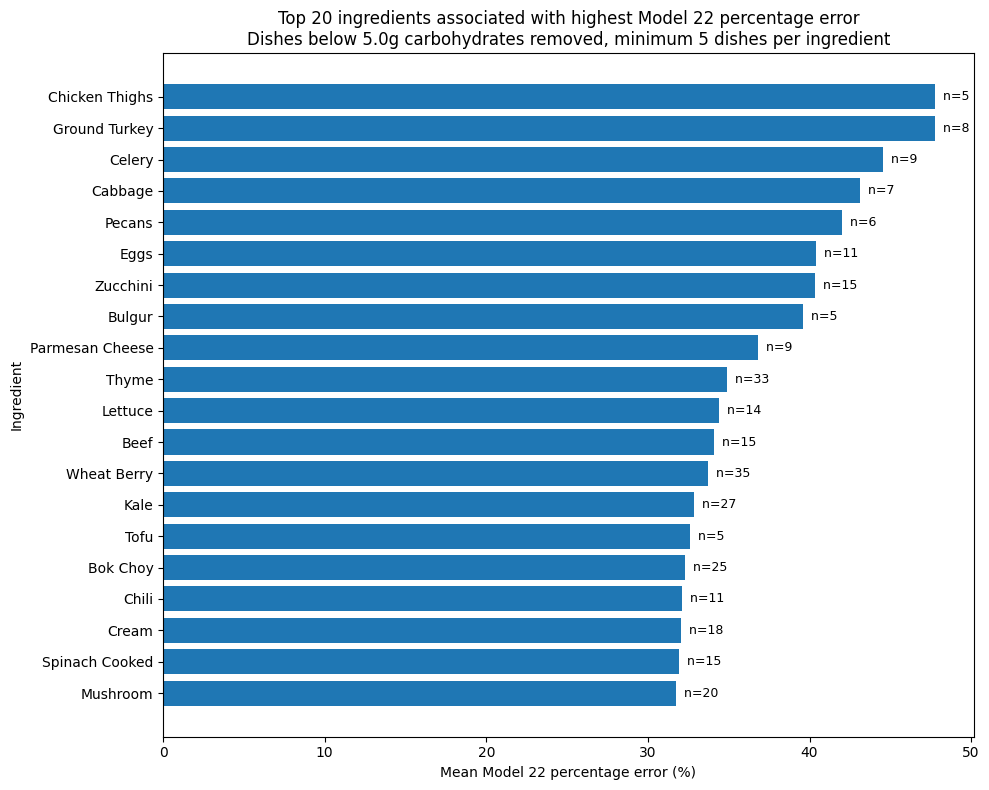

Saved top 20 percentage error plot to:
/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/ingredient_percentage_error_analysis/top20_ingredients_model22_percentage_error_min5g.png


In [ ]:
TOP_N = 20

top20_ingredients = ingredient_summary.head(TOP_N).copy()

# Reverse so highest appears at the top
top20_ingredients = top20_ingredients.sort_values(
    "mean_model22_percentage_error",
    ascending=True
)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    top20_ingredients["ingredient_clean"],
    top20_ingredients["mean_model22_percentage_error"]
)

plt.xlabel("Mean Model 22 percentage error (%)")
plt.ylabel("Ingredient")
plt.title(
    f"Top {TOP_N} ingredients associated with highest Model 22 percentage error\n"
    f"Dishes below {MIN_CARB_THRESHOLD}g carbohydrates removed, minimum {MIN_DISH_COUNT} dishes per ingredient"
)

for bar, dish_count in zip(bars, top20_ingredients["dish_count"]):
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"  n={dish_count}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plot_top20_path = OUTPUT_DIR / "top20_ingredients_model22_percentage_error_min5g.png"

plt.savefig(plot_top20_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved top 20 percentage error plot to:")
print(plot_top20_path)

Full ingredient plotting

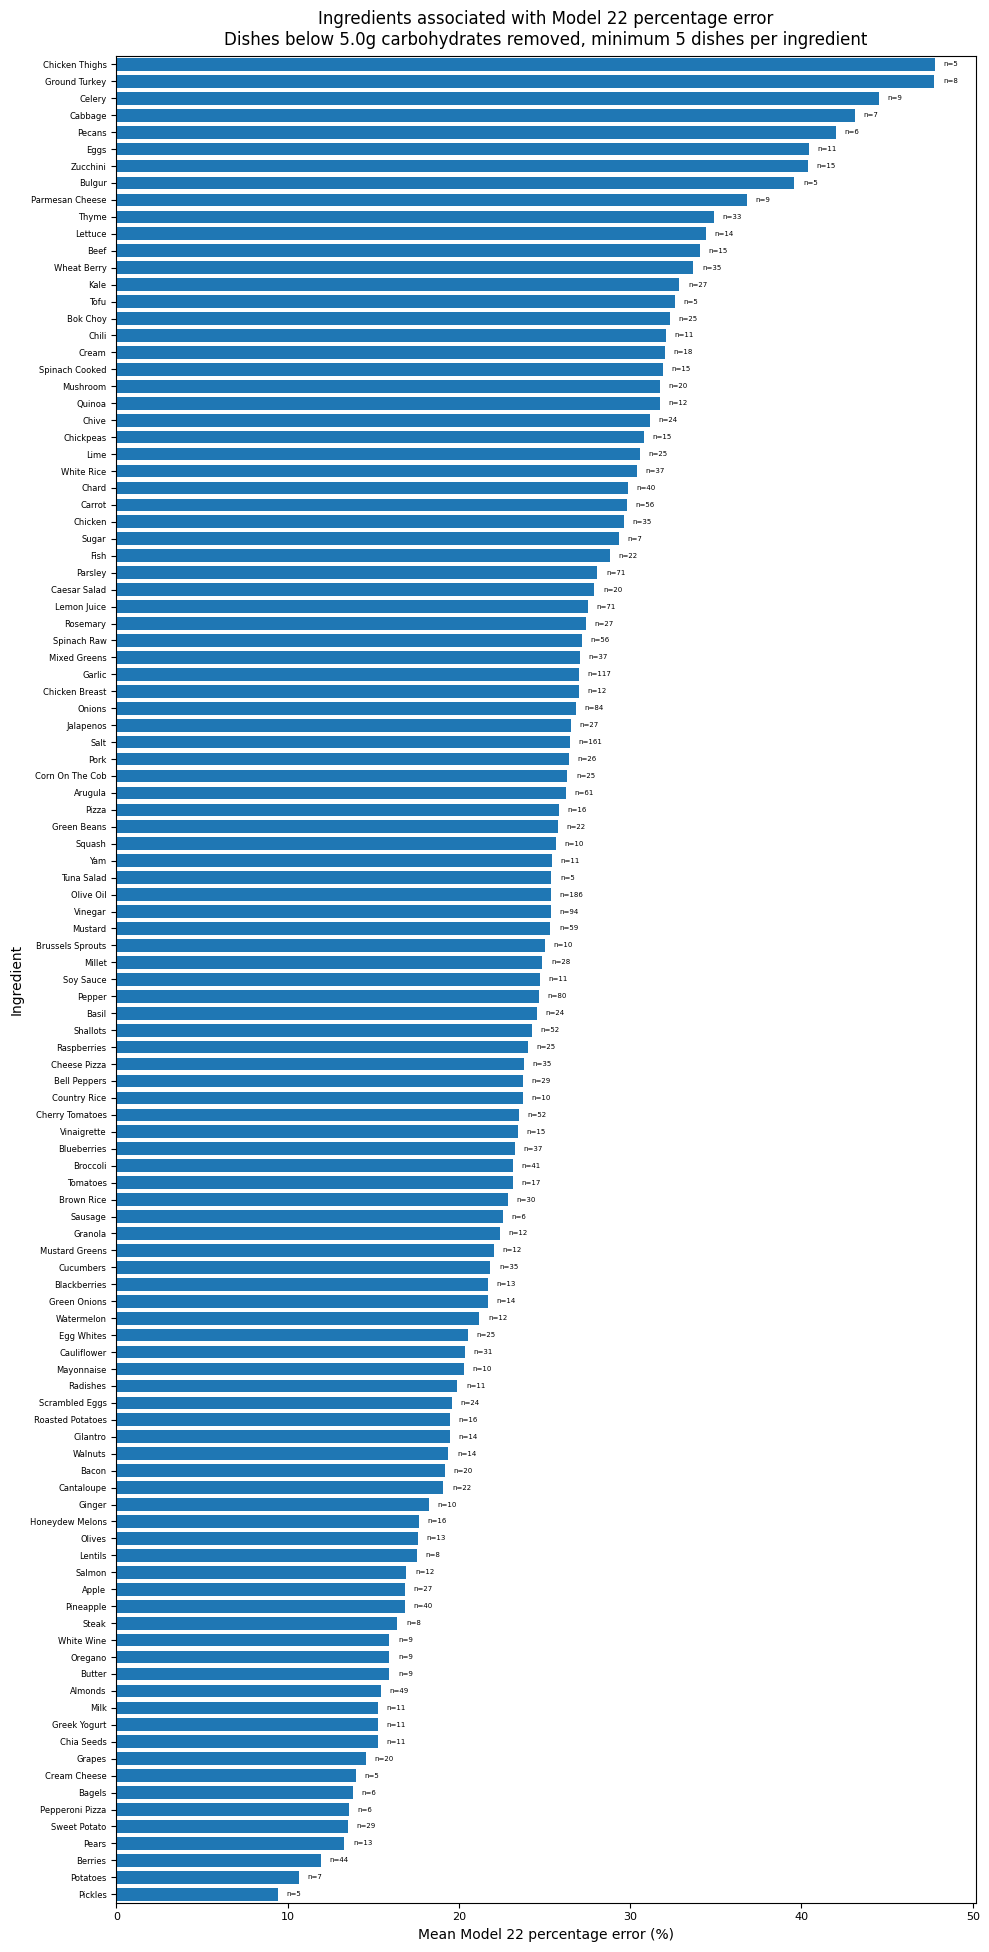

Saved PNG to:
/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/ingredient_percentage_error_analysis/ingredients_model22_percentage_error_full_appendix_min5g.png
Saved PDF to:
/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/ingredient_percentage_error_analysis/ingredients_model22_percentage_error_full_appendix_min5g.pdf


In [ ]:
TOP_N = len(ingredient_summary)

ingredients_percentage = ingredient_summary.head(TOP_N).copy()

# Reverse so highest appears at the top
ingredients_percentage = ingredients_percentage.sort_values(
    "mean_model22_percentage_error",
    ascending=True
).reset_index(drop=True)

fig_height = max(12, len(ingredients_percentage) * 0.18)

fig, ax = plt.subplots(figsize=(10, fig_height))

bars = ax.barh(
    ingredients_percentage["ingredient_clean"],
    ingredients_percentage["mean_model22_percentage_error"],
    height=0.75
)

ax.set_xlabel("Mean Model 22 percentage error (%)")
ax.set_ylabel("Ingredient")
ax.set_title(
    "Ingredients associated with Model 22 percentage error\n"
    f"Dishes below {MIN_CARB_THRESHOLD}g carbohydrates removed, minimum {MIN_DISH_COUNT} dishes per ingredient",
    pad=8
)

# Tight y-axis limits to remove unnecessary empty space
ax.set_ylim(-0.5, len(ingredients_percentage) - 0.5)

# Smaller tick labels for appendix figure
ax.tick_params(axis="y", labelsize=6)
ax.tick_params(axis="x", labelsize=8)

# Add dish-count labels
for bar, dish_count in zip(bars, ingredients_percentage["dish_count"]):
    width = bar.get_width()

    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"n={dish_count}",
        va="center",
        ha="left",
        fontsize=5
    )

fig.tight_layout()

plot_full_png_path = OUTPUT_DIR / "ingredients_model22_percentage_error_full_appendix_min5g.png"
plot_full_pdf_path = OUTPUT_DIR / "ingredients_model22_percentage_error_full_appendix_min5g.pdf"

fig.savefig(plot_full_png_path, dpi=300, bbox_inches="tight")
fig.savefig(plot_full_pdf_path, bbox_inches="tight")

plt.show()

print("Saved PNG to:")
print(plot_full_png_path)

print("Saved PDF to:")
print(plot_full_pdf_path)

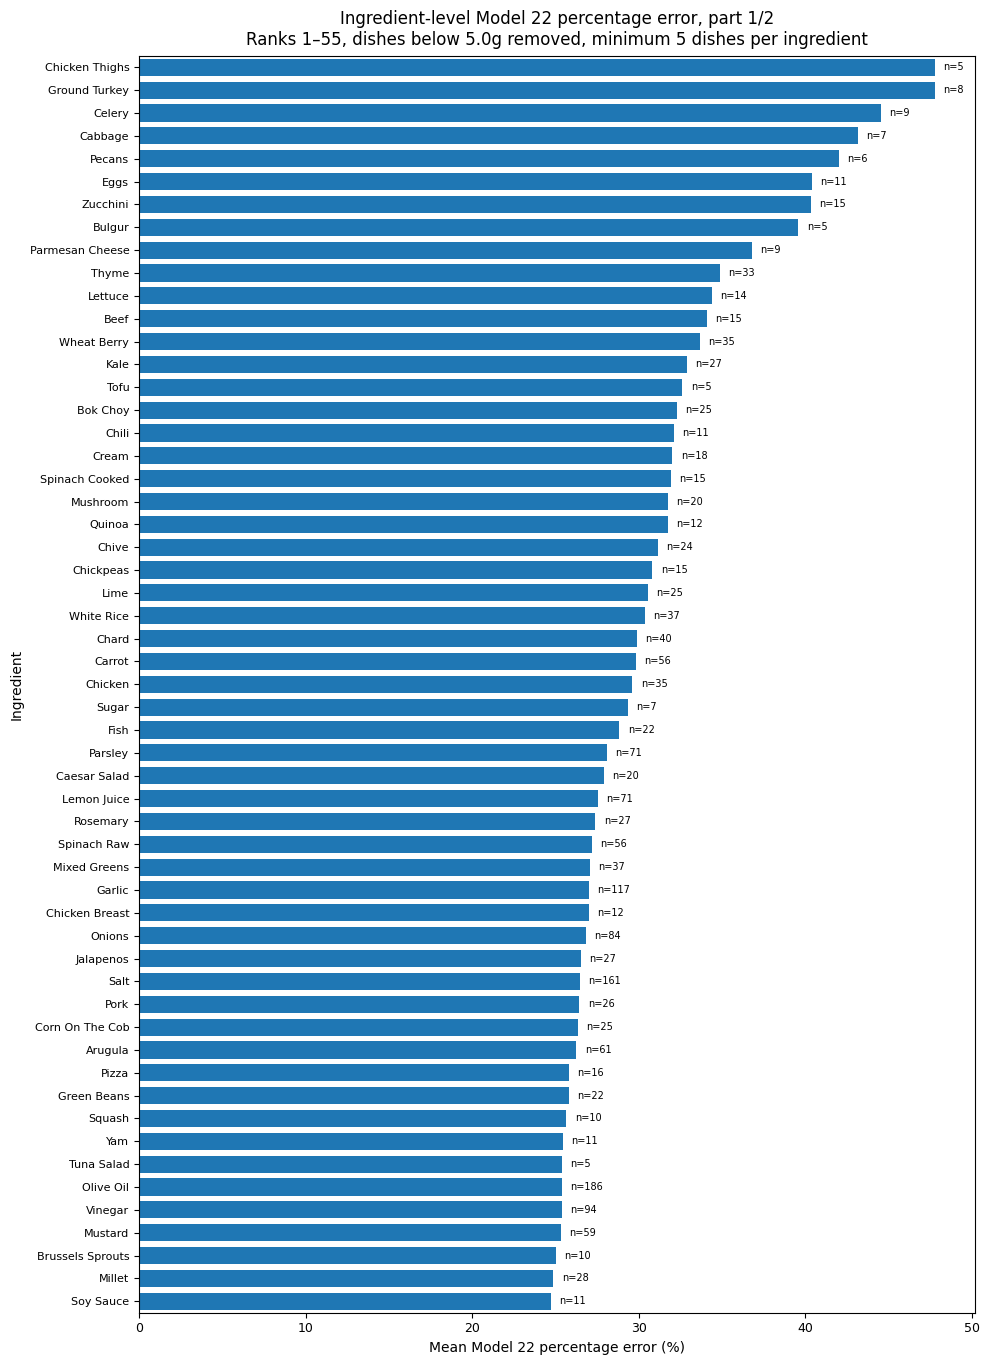

Saved part 1:
/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/ingredient_percentage_error_analysis/ingredients_model22_percentage_error_appendix_min5g_part_1.png
/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/ingredient_percentage_error_analysis/ingredients_model22_percentage_error_appendix_min5g_part_1.pdf


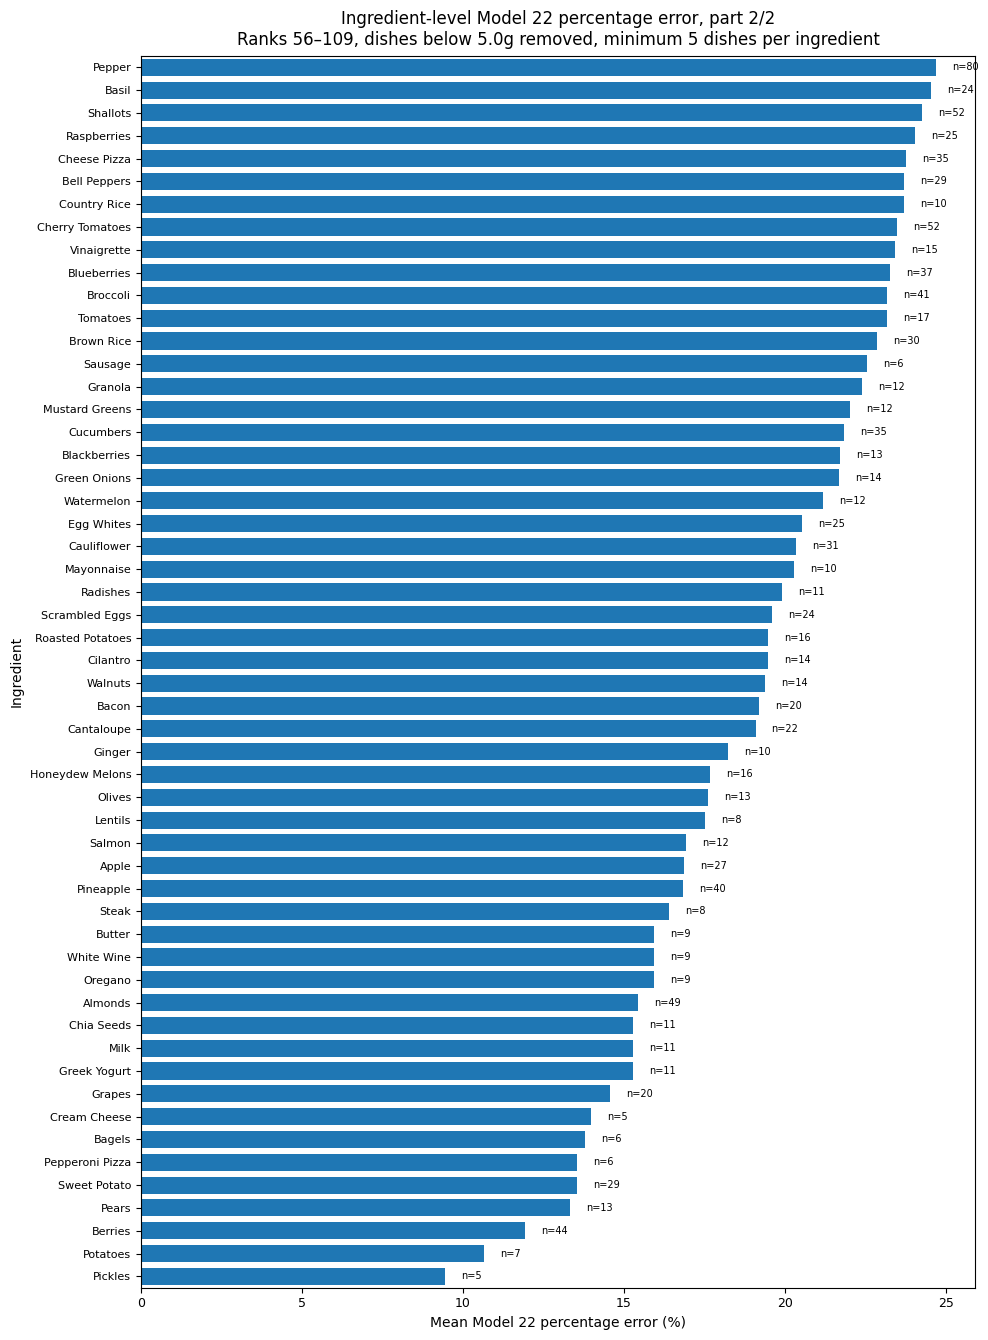

Saved part 2:
/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/ingredient_percentage_error_analysis/ingredients_model22_percentage_error_appendix_min5g_part_2.png
/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/ingredient_percentage_error_analysis/ingredients_model22_percentage_error_appendix_min5g_part_2.pdf


In [ ]:
CHUNK_SIZE = 55

ingredients_percentage_all = ingredient_summary.copy()

# Sort from highest to lowest for chunking
ingredients_percentage_all = ingredients_percentage_all.sort_values(
    "mean_model22_percentage_error",
    ascending=False
).reset_index(drop=True)

num_chunks = int(np.ceil(len(ingredients_percentage_all) / CHUNK_SIZE))

for chunk_idx in range(num_chunks):
    start = chunk_idx * CHUNK_SIZE
    end = min(start + CHUNK_SIZE, len(ingredients_percentage_all))

    chunk_df = ingredients_percentage_all.iloc[start:end].copy()

    # Reverse for barh so highest in this chunk appears at top
    chunk_df = chunk_df.sort_values(
        "mean_model22_percentage_error",
        ascending=True
    ).reset_index(drop=True)

    fig_height = max(8, len(chunk_df) * 0.25)

    fig, ax = plt.subplots(figsize=(10, fig_height))

    bars = ax.barh(
        chunk_df["ingredient_clean"],
        chunk_df["mean_model22_percentage_error"],
        height=0.75
    )

    ax.set_xlabel("Mean Model 22 percentage error (%)")
    ax.set_ylabel("Ingredient")
    ax.set_title(
        f"Ingredient-level Model 22 percentage error, part {chunk_idx + 1}/{num_chunks}\n"
        f"Ranks {start + 1}–{end}, dishes below {MIN_CARB_THRESHOLD}g removed, minimum {MIN_DISH_COUNT} dishes per ingredient",
        pad=8
    )

    ax.set_ylim(-0.5, len(chunk_df) - 0.5)

    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=9)

    for bar, dish_count in zip(bars, chunk_df["dish_count"]):
        width = bar.get_width()

        ax.text(
            width + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"n={dish_count}",
            va="center",
            ha="left",
            fontsize=7
        )

    fig.tight_layout()

    chunk_png_path = OUTPUT_DIR / f"ingredients_model22_percentage_error_appendix_min5g_part_{chunk_idx + 1}.png"
    chunk_pdf_path = OUTPUT_DIR / f"ingredients_model22_percentage_error_appendix_min5g_part_{chunk_idx + 1}.pdf"

    fig.savefig(chunk_png_path, dpi=300, bbox_inches="tight")
    fig.savefig(chunk_pdf_path, bbox_inches="tight")

    plt.show()

    print(f"Saved part {chunk_idx + 1}:")
    print(chunk_png_path)
    print(chunk_pdf_path)